# 02 - Clasificación contextual de transacciones

## 1. Dependencias

In [1]:
#Instalar dependencias
%pip install pandas numpy scikit-learn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


## 2. Configuración

In [2]:
#Librerías
import platform
import sys
import unicodedata
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline

In [3]:
#Configuración
SEMILLA = 20260724
UMBRAL_USUARIO = 0.50
UMBRAL_TRANSACCION = 0.50
UMBRAL_CONFIRMACION = 0.50
UMBRAL_RECONCILIACION_FINALIDAD = 0.50
VERSION_MODELO = 'fincoah_transacciones_mvp_v1'

versiones = pd.DataFrame([
    {'componente': 'python', 'version': sys.version.split()[0]},
    {'componente': 'plataforma', 'version': platform.platform()},
    {'componente': 'pandas', 'version': pd.__version__},
    {'componente': 'numpy', 'version': np.__version__},
    {'componente': 'scikit-learn', 'version': sklearn.__version__},
])

display(versiones)

,componente,version
0,python,3.14.3
1,plataforma,macOS-26.5.2-arm64-arm-64bit-Mach-O
2,pandas,3.0.3
3,numpy,2.5.1
4,scikit-learn,1.9.0


## 3. Carga del dataset

In [4]:
#Rutas
ruta_perfiles = Path('../Datasets/perfil_integral_usuario.csv')
ruta_transacciones = Path('../Datasets/transacciones_contextualizadas.csv')
ruta_modelo_usuario = Path('../Modelos/01_conocimiento_usuario.joblib')

assert ruta_perfiles.exists(), f'No existe {ruta_perfiles}'
assert ruta_transacciones.exists(), f'No existe {ruta_transacciones}'
assert ruta_modelo_usuario.exists(), 'Ejecuta primero el notebook 01 para generar su modelo'

print(f'Perfiles: {ruta_perfiles}')
print(f'Transacciones: {ruta_transacciones}')
print(f'Modelo de usuario: {ruta_modelo_usuario}')

Perfiles: ../Datasets/perfil_integral_usuario.csv
Transacciones: ../Datasets/transacciones_contextualizadas.csv
Modelo de usuario: ../Modelos/01_conocimiento_usuario.joblib


In [5]:
#Cargar datos
perfiles = pd.read_csv(ruta_perfiles, low_memory=False)
transacciones = pd.read_csv(ruta_transacciones, low_memory=False)
artefacto_usuario = joblib.load(ruta_modelo_usuario)

display(perfiles.head(5))
display(transacciones.head(5))

,perfil_id,version_perfil,vigencia_desde,pais,moneda,descripcion_visible,nivel_informacion_visible,estado_alcance_mvp,actividad_1_familia,actividad_1_codigo_cuoc,...,informacion_extraible,informacion_no_determinable,historia_financiera_controlada,liquidez_inicial,deuda_inicial,consentimiento_analisis,particion,es_sintetico,version_esquema,huella_registro
0,PERF_0001,1,2026-04-01,Colombia,COP,Trabajo como ingeniero de software. En mi tiem...,parcial,dentro_del_mvp,ingenieria_y_desarrollo_de_software,25120,...,ingenieria_y_desarrollo_de_software | pintura ...,otras_fuentes_no_declaradas,acumulacion_estable,1662767,8031665,si,train,si,fincoah_mvp_co_v1.1,6934eab1186cb0d14cbb1e2e32f360f780c43a6593c4c5...
1,PERF_0002,1,2026-04-01,Colombia,COP,Trabajo como nutricionista dietista. Quiero am...,parcial,dentro_del_mvp,nutricion_y_dietetica,22650,...,nutricion_y_dietetica | ampliar_actividad_econ...,hobbies,equilibrio_sostenible,10224606,3753786,si,train,si,fincoah_mvp_co_v1.1,156edc1387400f86abb957f1d27c982eeeab204580ae70...
2,PERF_0003,1,2026-04-01,Colombia,COP,Trabajo como disc jockey. También genero ingre...,parcial,dentro_del_mvp,musica_y_entretenimiento_dj,26521,...,musica_y_entretenimiento_dj | diseno_audiovisu...,meta | responsabilidades,variable_resiliente,4102250,8758948,si,train,si,fincoah_mvp_co_v1.1,033dd82022ff3a8a5a9c7212642bf3f2609271e3f1e5da...
3,PERF_0004,1,2026-04-01,Colombia,COP,Trabajo como ciclista. También genero ingresos...,parcial,dentro_del_mvp,deporte_competitivo_ciclismo,34210,...,deporte_competitivo_ciclismo | nutricion_y_die...,meta,uso_planificado_reserva,22524685,17967899,si,train,si,fincoah_mvp_co_v1.1,ed2513da4b50c58e26180da5f8ad594f1aa541c3287ef0...
4,PERF_0005,1,2026-04-01,Colombia,COP,Trabajo como repartidor de domicilios. También...,parcial,dentro_del_mvp,domicilios_mensajeria_y_reparto,96211,...,domicilios_mensajeria_y_reparto | ventas_al_po...,meta,deterioro_reciente,6806139,4450913,si,train,si,fincoah_mvp_co_v1.1,62711219a09392a1a50f1b44c512bcdd5b3c990630958f...


,transaccion_id,perfil_id,version_perfil_aplicada,fecha,descripcion_original,descripcion_normalizada,valor,moneda,direccion,tipo_movimiento,...,evidencia_contextual,confianza_objetivo,etiqueta_revisada,canal,particion,historia_financiera_controlada,es_sintetico,version_taxonomia,version_esquema,huella_registro
0,TX_0001_0001,PERF_0001,1,2026-04-02,PAGO ARRIENDO,pago arriendo,427000,COP,salida,gasto,...,descripcion:pago arriendo,0.889,si,bancario,train,acumulacion_estable,si,roadmap_10.1_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,88094df9256d8c73dfaaaa0064ff648cacb74b09ef7a10...
1,TX_0001_0002,PERF_0001,1,2026-04-02,ALMUERZO,almuerzo,54000,COP,salida,gasto,...,descripcion:almuerzo,0.959,si,bancario,train,acumulacion_estable,si,roadmap_10.1_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,e8330155be5651fc75e38d1ae17581f9df3fcda8fe049b...
2,TX_0001_0003,PERF_0001,1,2026-04-03,REPUESTO TRANSPORTE,repuesto transporte,70000,COP,salida,gasto,...,descripcion:repuesto transporte,0.883,si,bancario,train,acumulacion_estable,si,roadmap_10.1_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,75f71d21196faceaa5104eac2b33e34c4d27cfbe9fb080...
3,TX_0001_0004,PERF_0001,1,2026-04-03,HOTEL TURISMO,hotel turismo,90000,COP,salida,gasto,...,hobby:turismo_y_viajes | descripcion:hotel tur...,0.956,si,bancario,train,acumulacion_estable,si,roadmap_10.1_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,63d918762cbf8d02bd0ce8c493b569f18af661609cd2d4...
4,TX_0001_0005,PERF_0001,1,2026-04-05,APP DOMICILIO COMIDA,app domicilio comida,53000,COP,salida,gasto,...,descripcion:app domicilio comida,0.924,si,bancario,train,acumulacion_estable,si,roadmap_10.1_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,168d79be301ae7899921bc1f52cb80866ac3d8ce41d33b...


## 4. Contrato y unión contextual

In [7]:
#validar contrato
columnas_transacciones = [
    'transaccion_id',
    'perfil_id',
    'descripcion_original',
    'descripcion_normalizada',
    'valor',
    'direccion',
    'tipo_movimiento',
    'categoria_principal',
    'finalidad',
    'nota_usuario',
    'estado_clasificacion',
    'requiere_confirmacion',
    'particion',
]

columnas_perfiles = [
    'perfil_id',
    'descripcion_visible',
    'actividad_1_familia',
    'actividad_2_familia',
    'actividad_2_visible',
    'hobby_1',
    'hobby_2',
    'meta_declarada',
    'responsabilidad_declarada',
    'informacion_extraible',
]

faltantes_transacciones = [
    columna for columna in columnas_transacciones if columna not in transacciones.columns
]

faltantes_perfiles = [
    columna for columna in columnas_perfiles if columna not in perfiles.columns
]

assert not faltantes_transacciones, f'Faltan columnas en transacciones: {faltantes_transacciones}'
assert not faltantes_perfiles, f'Faltan columnas en perfiles: {faltantes_perfiles}'
assert transacciones['transaccion_id'].is_unique, 'transaccion_id contiene duplicados'
assert perfiles['perfil_id'].is_unique, 'perfil_id contiene duplicados'
assert set(transacciones['particion'].unique()) == {'train', 'validation', 'test'}, 'Particiones inválidas'

print('Contrato: OK')

Contrato: OK


In [8]:
#Contexto
datos = transacciones.merge(
    perfiles[columnas_perfiles],
    on='perfil_id',
    how='left',
    validate='many_to_one',
)

perfiles_sin_contexto = datos['descripcion_visible'].isna().sum()
cruce_particiones = datos.groupby('perfil_id')['particion'].nunique()

assert perfiles_sin_contexto == 0, 'Existen transacciones sin perfil asociado'
assert cruce_particiones.eq(1).all(), 'Un perfil aparece en más de una partición'

display(pd.DataFrame([{
    'transacciones': len(datos),
    'perfiles': datos['perfil_id'].nunique(),
    'sin_contexto': int(perfiles_sin_contexto),
}]))

,transacciones,perfiles,sin_contexto
0,19077,200,0


## 5. Cobertura de etiquetas

In [9]:
#Mostrar cobertura
resumen_etiquetas = pd.DataFrame([
    {
        'objetivo': 'categoria_principal',
        'clases': datos['categoria_principal'].nunique(),
        'clase_menor': datos['categoria_principal'].value_counts().idxmin(),
        'filas_clase_menor': int(datos['categoria_principal'].value_counts().min()),
    },
    
    {
        'objetivo': 'finalidad',
        'clases': datos['finalidad'].nunique(),
        'clase_menor': datos['finalidad'].value_counts().idxmin(),
        'filas_clase_menor': int(datos['finalidad'].value_counts().min()),
    },
    
    {
        'objetivo': 'requiere_confirmacion',
        'clases': datos['requiere_confirmacion'].nunique(),
        'clase_menor': datos['requiere_confirmacion'].value_counts().idxmin(),
        'filas_clase_menor': int(datos['requiere_confirmacion'].value_counts().min()),
    },
])

display(resumen_etiquetas)
display(pd.crosstab(datos['categoria_principal'], datos['particion']))

,objetivo,clases,clase_menor,filas_clase_menor
0,categoria_principal,20,Rentas y rendimientos,40
1,finalidad,14,apoyo_externo,40
2,requiere_confirmacion,2,si,558


particion,test,train,validation
categoria_principal,,,
Alimentación,229,993,212
Apoyos recibidos,9,25,6
Deuda y financiación,88,441,124
Deuda y financiación recibida,21,98,23
Devoluciones y reembolsos,26,97,17
Educación,147,610,145
Ingresos laborales,56,254,41
Inversión productiva,261,1108,273
Ocio,363,1555,291


In [10]:
#Validar cobertura
cobertura_categoria = pd.crosstab(
    datos['categoria_principal'],
    datos['particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)

cobertura_finalidad = pd.crosstab(
    datos['finalidad'],
    datos['particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)

assert cobertura_categoria.gt(0).all(axis=1).all(), 'Alguna categoría no aparece en las tres particiones'
assert cobertura_finalidad.gt(0).all(axis=1).all(), 'Alguna finalidad no aparece en las tres particiones'
print('Cobertura de etiquetas: OK')

Cobertura de etiquetas: OK


## 6. Ingeniería de atributos

In [12]:
#Preparar contexto
def valor_texto(valor, reemplazo='no_declarado'):
    if pd.isna(valor) or not str(valor).strip():
        return reemplazo
    return str(valor).strip()


def hobbies_visibles(fila):
    informacion_visible = set(str(fila['informacion_extraible']).split(' | '))
    hobbies = [
        hobby
        for hobby in [fila['hobby_1'], fila['hobby_2']]
        if pd.notna(hobby) and hobby in informacion_visible
    ]
    return hobbies if hobbies else ['no_declarado']


datos['actividad_secundaria_modelo'] = np.where(
    datos['actividad_2_visible'].eq('si'),
    datos['actividad_2_familia'].fillna('no_declarada'),
    'no_declarada',
)

datos['hobbies_modelo'] = datos.apply(hobbies_visibles, axis=1)
datos['meta_modelo'] = datos['meta_declarada'].fillna('no_declarada')
datos['responsabilidad_modelo'] = datos['responsabilidad_declarada'].fillna('no_declarada')

In [13]:
#Construir atributos
def construir_texto_modelo(fila):
    hobbies = fila['hobbies_modelo']
    if isinstance(hobbies, list):
        hobbies = ' '.join(hobbies)

    partes = [
        'transaccion {}'.format(valor_texto(fila['descripcion_normalizada'])),
        'nota {}'.format(valor_texto(fila['nota_usuario'])),
        'direccion {}'.format(valor_texto(fila['direccion'])),
        'tipo {}'.format(valor_texto(fila['tipo_movimiento'])),
        'usuario {}'.format(valor_texto(fila['descripcion_visible'])),
        'actividad {}'.format(valor_texto(fila['actividad_1_familia'])),
        'actividad secundaria {}'.format(valor_texto(fila['actividad_secundaria_modelo'])),
        'hobbies {}'.format(valor_texto(hobbies)),
        'meta {}'.format(valor_texto(fila['meta_modelo'])),
        'responsabilidad {}'.format(valor_texto(fila['responsabilidad_modelo'])),
    ]
    return ' | '.join(partes)


mascara_train = datos['particion'].eq('train')
mascara_validation = datos['particion'].eq('validation')
mascara_test = datos['particion'].eq('test')
escala_valor = float(np.log1p(pd.to_numeric(datos.loc[mascara_train, 'valor'])).max())

datos['texto_modelo'] = datos.apply(construir_texto_modelo, axis=1)
datos['valor_modelo'] = np.log1p(pd.to_numeric(datos['valor'])) / escala_valor

columnas_modelo = ['texto_modelo', 'valor_modelo']
X_train = datos.loc[mascara_train, columnas_modelo]
X_validation = datos.loc[mascara_validation, columnas_modelo]
X_test = datos.loc[mascara_test, columnas_modelo]

display(datos[columnas_modelo].head(5))

,texto_modelo,valor_modelo
0,transaccion pago arriendo | nota no_declarado ...,0.811113
1,transaccion almuerzo | nota no_declarado | dir...,0.681744
2,transaccion repuesto transporte | nota no_decl...,0.697980
3,transaccion hotel turismo | nota no_declarado ...,0.713703
4,transaccion app domicilio comida | nota no_dec...,0.680575


## 7. Categoría principal

In [14]:
#Definir modelos
def crear_preprocesador():
    return ColumnTransformer([
        (
            'texto',
            TfidfVectorizer(
                analyzer='char_wb',
                ngram_range=(3, 5),
                lowercase=True,
                strip_accents='unicode',
                min_df=2,
                max_features=40000,
                sublinear_tf=True,
            ),
            'texto_modelo',
        ),
        ('valor', 'passthrough', ['valor_modelo']),
    ])


def crear_pipeline(clasificador):
    return Pipeline([
        ('preprocesamiento', crear_preprocesador()),
        ('clasificador', clasificador),
    ])


candidatos_categoria = {
    'regresion_logistica_sgd': crear_pipeline(SGDClassifier(
        loss='log_loss',
        alpha=0.00001,
        max_iter=2000,
        class_weight='balanced',
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=10,
        average=True,
        random_state=SEMILLA,
    )),
    'naive_bayes_complementario': crear_pipeline(ComplementNB(alpha=0.35)),
}

In [15]:
#Comparar categorías
y_categoria_train = datos.loc[mascara_train, 'categoria_principal']
y_categoria_validation = datos.loc[mascara_validation, 'categoria_principal']
y_categoria_test = datos.loc[mascara_test, 'categoria_principal']
metricas_candidatos = []

for nombre, modelo in candidatos_categoria.items():
    modelo.fit(X_train, y_categoria_train)
    prediccion = modelo.predict(X_validation)
    metricas_candidatos.append({
        'modelo': nombre,
        'f1_macro_validation': f1_score(
            y_categoria_validation,
            prediccion,
            average='macro',
            zero_division=0,
        ),
        'accuracy_validation': accuracy_score(y_categoria_validation, prediccion),
    })

metricas_candidatos = pd.DataFrame(metricas_candidatos)
puntajes_categoria = metricas_candidatos.set_index('modelo')['f1_macro_validation'].to_dict()
nombre_modelo_categoria = max(
    candidatos_categoria,
    key=lambda nombre: (puntajes_categoria[nombre], nombre == 'regresion_logistica_sgd'),
)

modelo_categoria = candidatos_categoria[nombre_modelo_categoria]
display(metricas_candidatos.sort_values('f1_macro_validation', ascending=False))
print(f'Modelo seleccionado: {nombre_modelo_categoria}')

,modelo,f1_macro_validation,accuracy_validation
0,regresion_logistica_sgd,0.999800,0.999650
1,naive_bayes_complementario,0.941549,0.946097


Modelo seleccionado: regresion_logistica_sgd


In [16]:
#Evaluar categorías
prediccion_categoria_test = modelo_categoria.predict(X_test)
reporte_categoria = classification_report(
    y_categoria_test,
    prediccion_categoria_test,
    output_dict=True,
    zero_division=0,
)

resumen_categoria = pd.DataFrame([{
    'modelo': nombre_modelo_categoria,
    'f1_macro_test': f1_score(
        y_categoria_test,
        prediccion_categoria_test,
        average='macro',
        zero_division=0,
    ),
    'accuracy_test': accuracy_score(y_categoria_test, prediccion_categoria_test),
    'transacciones_test': len(y_categoria_test),
}])

metricas_categoria = pd.DataFrame(reporte_categoria).T.loc[
    sorted(y_categoria_test.unique()),
    ['precision', 'recall', 'f1-score', 'support'],
]

display(resumen_categoria)
display(metricas_categoria)

,modelo,f1_macro_test,accuracy_test,transacciones_test
0,regresion_logistica_sgd,0.998098,0.996842,2850


,precision,recall,f1-score,support
Alimentación,1.000000,1.000000,1.000000,229.0
Apoyos recibidos,1.000000,1.000000,1.000000,9.0
Deuda y financiación,1.000000,1.000000,1.000000,88.0
Deuda y financiación recibida,1.000000,1.000000,1.000000,21.0
Devoluciones y reembolsos,1.000000,1.000000,1.000000,26.0
Educación,1.000000,1.000000,1.000000,147.0
Ingresos laborales,1.000000,1.000000,1.000000,56.0
Inversión productiva,1.000000,0.969349,0.984436,261.0
Ocio,1.000000,1.000000,1.000000,363.0
Otra / ambigua,1.000000,1.000000,1.000000,42.0


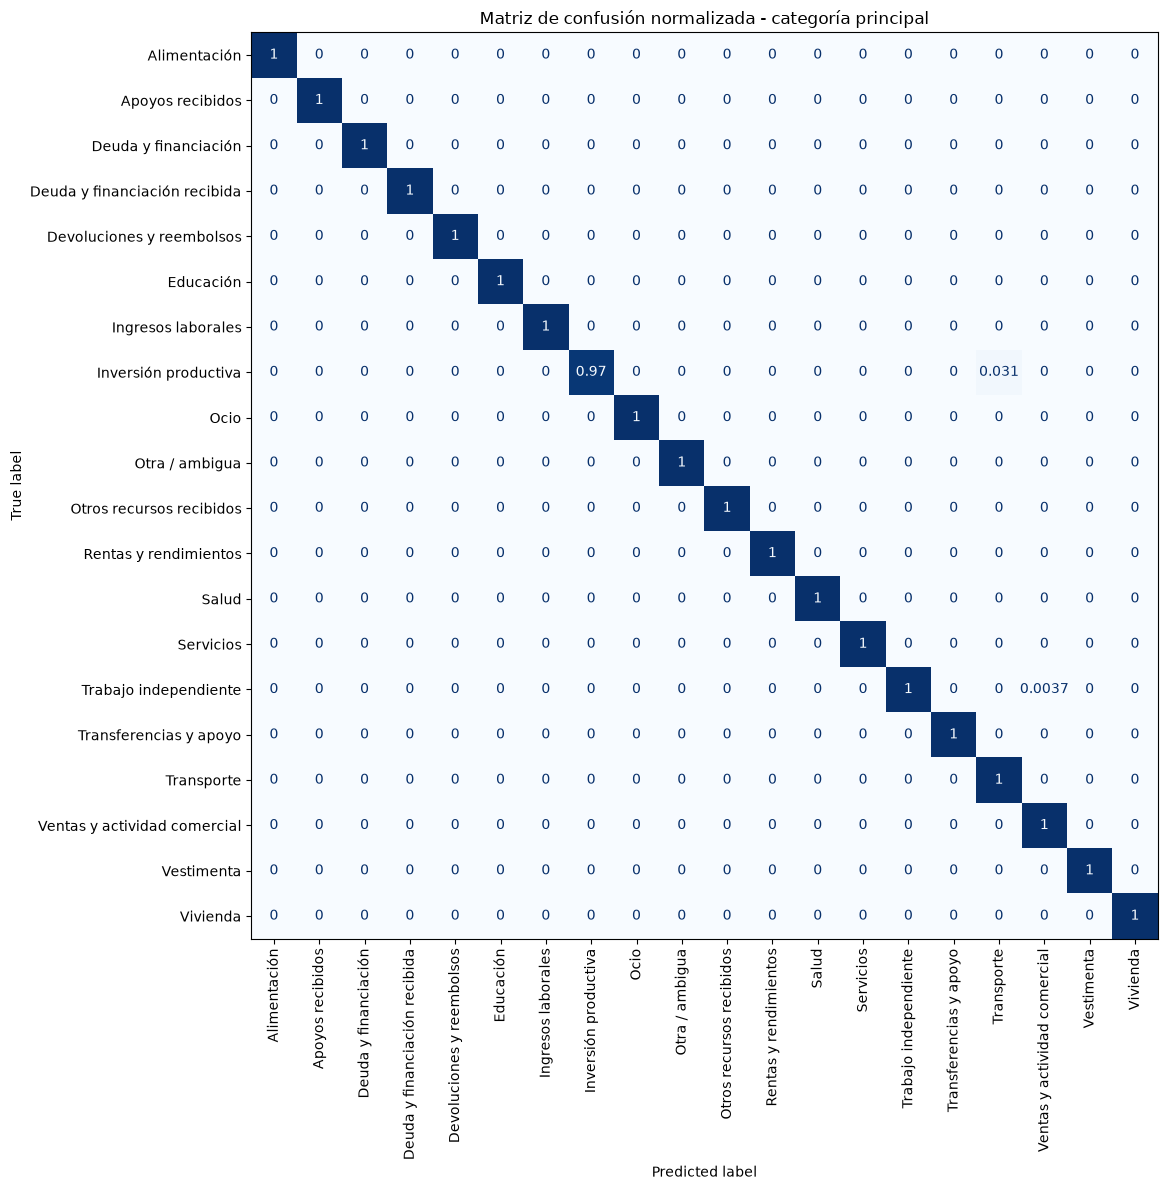

In [17]:
#Mostrar confusión
figura, eje = plt.subplots(figsize=(14, 12))

ConfusionMatrixDisplay.from_predictions(
    y_categoria_test,
    prediccion_categoria_test,
    labels=sorted(y_categoria_test.unique()),
    normalize='true',
    xticks_rotation=90,
    cmap='Blues',
    ax=eje,
    colorbar=False,
)

eje.set_title('Matriz de confusión normalizada - categoría principal')
plt.tight_layout()
plt.show()

## 8. Finalidad y confirmación

In [18]:
#Entrenar finalidad
modelo_finalidad = crear_pipeline(SGDClassifier(
    loss='log_loss',
    alpha=0.00001,
    max_iter=2000,
    class_weight='balanced',
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=10,
    average=True,
    random_state=SEMILLA,
))

y_finalidad_train = datos.loc[mascara_train, 'finalidad']
y_finalidad_validation = datos.loc[mascara_validation, 'finalidad']
y_finalidad_test = datos.loc[mascara_test, 'finalidad']

modelo_finalidad.fit(X_train, y_finalidad_train)
prediccion_finalidad_validation = modelo_finalidad.predict(X_validation)
prediccion_finalidad_test = modelo_finalidad.predict(X_test)

metricas_finalidad = pd.DataFrame([{
    'f1_macro_validation': f1_score(
        y_finalidad_validation,
        prediccion_finalidad_validation,
        average='macro',
        zero_division=0,
    ),
    'f1_macro_test': f1_score(
        y_finalidad_test,
        prediccion_finalidad_test,
        average='macro',
        zero_division=0,
    ),
    'accuracy_test': accuracy_score(y_finalidad_test, prediccion_finalidad_test),
}])

display(metricas_finalidad)

,f1_macro_validation,f1_macro_test,accuracy_test
0,0.990299,0.989128,0.995088


In [19]:
#Reconciliar finalidad
tabla_compatibilidad = pd.crosstab(
    datos.loc[mascara_train, 'finalidad'],
    datos.loc[mascara_train, 'categoria_principal'],
).gt(0)

categorias_por_finalidad = {
    finalidad: tabla_compatibilidad.columns[fila.to_numpy()].tolist()
    for finalidad, fila in tabla_compatibilidad.iterrows()
}


def reconciliar_probabilidades(probabilidades, finalidad, confianza_finalidad):
    probabilidades_ajustadas = np.asarray(probabilidades, dtype=float).copy()
    categorias_permitidas = categorias_por_finalidad.get(finalidad, [])

    if confianza_finalidad >= UMBRAL_RECONCILIACION_FINALIDAD and categorias_permitidas:
        mascara_permitida = np.isin(modelo_categoria.classes_, categorias_permitidas)
        probabilidades_ajustadas = probabilidades_ajustadas * mascara_permitida
        total = probabilidades_ajustadas.sum()
        if total > 0:
            probabilidades_ajustadas = probabilidades_ajustadas / total

    return probabilidades_ajustadas


probabilidades_categoria_test = modelo_categoria.predict_proba(X_test)
probabilidades_finalidad_test = modelo_finalidad.predict_proba(X_test)
predicciones_reconciliadas = []

for posicion in range(len(X_test)):
    posicion_finalidad = int(np.argmax(probabilidades_finalidad_test[posicion]))
    finalidad = modelo_finalidad.classes_[posicion_finalidad]
    confianza_finalidad = float(probabilidades_finalidad_test[posicion, posicion_finalidad])
    probabilidades_ajustadas = reconciliar_probabilidades(
        probabilidades_categoria_test[posicion],
        finalidad,
        confianza_finalidad,
    )
    predicciones_reconciliadas.append(
        modelo_categoria.classes_[int(np.argmax(probabilidades_ajustadas))]
    )

metricas_reconciliacion = pd.DataFrame([{
    'f1_macro_categoria_sin_reconciliar': f1_score(
        y_categoria_test,
        prediccion_categoria_test,
        average='macro',
        zero_division=0,
    ),
    'f1_macro_categoria_reconciliada': f1_score(
        y_categoria_test,
        predicciones_reconciliadas,
        average='macro',
        zero_division=0,
    ),
    'accuracy_categoria_reconciliada': accuracy_score(
        y_categoria_test,
        predicciones_reconciliadas,
    ),
}])

display(tabla_compatibilidad)
display(metricas_reconciliacion)

categoria_principal,Alimentación,Apoyos recibidos,Deuda y financiación,Deuda y financiación recibida,Devoluciones y reembolsos,Educación,Ingresos laborales,Inversión productiva,Ocio,Otra / ambigua,Otros recursos recibidos,Rentas y rendimientos,Salud,Servicios,Trabajo independiente,Transferencias y apoyo,Transporte,Ventas y actividad comercial,Vestimenta,Vivienda
finalidad,,,,,,,,,,,,,,,,,,,,
apoyo_externo,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
apoyo_terceros,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
consumo_mixto,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False
consumo_personal,True,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,True,False,True,True
generacion_ingreso,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,True,False,False
hobby,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
indeterminado,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
laboral,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False
liquidez_financiada,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


,f1_macro_categoria_sin_reconciliar,f1_macro_categoria_reconciliada,accuracy_categoria_reconciliada
0,0.998098,0.998098,0.996842


In [20]:
#Entrenar confirmación
modelo_confirmacion = crear_pipeline(SGDClassifier(
    loss='log_loss',
    alpha=0.00001,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=10,
    average=True,
    random_state=SEMILLA,
))

y_confirmacion_train = datos.loc[mascara_train, 'requiere_confirmacion']
y_confirmacion_validation = datos.loc[mascara_validation, 'requiere_confirmacion']
y_confirmacion_test = datos.loc[mascara_test, 'requiere_confirmacion']

modelo_confirmacion.fit(X_train, y_confirmacion_train)
probabilidades_confirmacion_validation = modelo_confirmacion.predict_proba(X_validation)
posicion_confirmacion_si = list(modelo_confirmacion.classes_).index('si')
probabilidad_si_validation = probabilidades_confirmacion_validation[:, posicion_confirmacion_si]
resultados_umbrales_confirmacion = []

for umbral in np.arange(0.10, 0.96, 0.05):
    prediccion = np.where(probabilidad_si_validation >= umbral, 'si', 'no')
    resultados_umbrales_confirmacion.append({
        'umbral': round(float(umbral), 2),
        'f1_confirmacion': f1_score(
            y_confirmacion_validation,
            prediccion,
            pos_label='si',
            zero_division=0,
        ),
        'precision_confirmacion': precision_score(
            y_confirmacion_validation,
            prediccion,
            pos_label='si',
            zero_division=0,
        ),
        'recall_confirmacion': recall_score(
            y_confirmacion_validation,
            prediccion,
            pos_label='si',
            zero_division=0,
        ),
    })

resultados_umbrales_confirmacion = pd.DataFrame(resultados_umbrales_confirmacion)
UMBRAL_CONFIRMACION = float(
    resultados_umbrales_confirmacion.sort_values(
        ['f1_confirmacion', 'precision_confirmacion', 'umbral'],
        ascending=[False, False, False],
    ).iloc[0]['umbral']
)

probabilidades_confirmacion_test = modelo_confirmacion.predict_proba(X_test)
probabilidad_si_test = probabilidades_confirmacion_test[:, posicion_confirmacion_si]
prediccion_confirmacion_validation = np.where(
    probabilidad_si_validation >= UMBRAL_CONFIRMACION,
    'si',
    'no',
)
prediccion_confirmacion_test = np.where(
    probabilidad_si_test >= UMBRAL_CONFIRMACION,
    'si',
    'no',
)

reporte_confirmacion = classification_report(
    y_confirmacion_test,
    prediccion_confirmacion_test,
    output_dict=True,
    zero_division=0,
)

metricas_confirmacion = pd.DataFrame([{
    'f1_macro_validation': f1_score(
        y_confirmacion_validation,
        prediccion_confirmacion_validation,
        average='macro',
        zero_division=0,
    ),
    'f1_macro_test': f1_score(
        y_confirmacion_test,
        prediccion_confirmacion_test,
        average='macro',
        zero_division=0,
    ),
    'recall_requiere_confirmacion_test': reporte_confirmacion['si']['recall'],
    'precision_requiere_confirmacion_test': reporte_confirmacion['si']['precision'],
}])

display(resultados_umbrales_confirmacion)
display(metricas_confirmacion)
print(f'Umbral de confirmación seleccionado: {UMBRAL_CONFIRMACION:.2f}')

,umbral,f1_confirmacion,precision_confirmacion,recall_confirmacion
0,0.10,0.523364,0.417910,0.7000
1,0.15,0.621622,0.676471,0.5750
2,0.20,0.676692,0.849057,0.5625
3,0.25,0.687500,0.916667,0.5500
4,0.30,0.709677,1.000000,0.5500
5,0.35,0.699187,1.000000,0.5375
6,0.40,0.688525,1.000000,0.5250
7,0.45,0.677686,1.000000,0.5125
8,0.50,0.655462,1.000000,0.4875
9,0.55,0.620690,1.000000,0.4500


,f1_macro_validation,f1_macro_test,recall_requiere_confirmacion_test,precision_requiere_confirmacion_test
0,0.851619,0.849232,0.544304,1.0


Umbral de confirmación seleccionado: 0.30


In [21]:
#Evaluar abstención
probabilidades_categoria_validation = modelo_categoria.predict_proba(X_validation)
confianza_categoria_validation = probabilidades_categoria_validation.max(axis=1)
aceptadas = confianza_categoria_validation >= UMBRAL_TRANSACCION

exactitud_aceptadas = accuracy_score(
    y_categoria_validation[aceptadas],
    modelo_categoria.predict(X_validation)[aceptadas],
) if aceptadas.any() else np.nan

resumen_abstencion = pd.DataFrame([{
    'umbral': UMBRAL_TRANSACCION,
    'cobertura_validation_pct': round(float(aceptadas.mean()) * 100, 2),
    'abstencion_validation_pct': round(float((~aceptadas).mean()) * 100, 2),
    'accuracy_en_aceptadas': exactitud_aceptadas,
}])

display(resumen_abstencion)

,umbral,cobertura_validation_pct,abstencion_validation_pct,accuracy_en_aceptadas
0,0.5,99.79,0.21,0.999649


## 9. Uso del modelo de usuario

In [22]:
#Separar descripción
def normalizar_texto(texto):
    texto_normalizado = unicodedata.normalize('NFKD', str(texto))
    texto_sin_tildes = ''.join(
        caracter
        for caracter in texto_normalizado
        if not unicodedata.combining(caracter)
    )
    return ' '.join(texto_sin_tildes.lower().strip().split())


def cortar_al_final(texto, finales):
    segmento = texto
    for final in finales:
        if final in segmento:
            segmento = segmento.split(final, 1)[0]
    return segmento.strip(' .,:;')


def extraer_actividad_principal(texto):
    texto_normalizado = normalizar_texto(texto)
    return cortar_al_final(
        texto_normalizado,
        ['.', ' tambien ', ' en mi tiempo libre ', ' quiero ', ' tengo como responsabilidad '],
    )


def extraer_actividad_secundaria(texto):
    texto_normalizado = normalizar_texto(texto)
    marcadores = [
        'tambien genero ingresos con ',
        'tambien trabajo como ',
        'ademas genero ingresos con ',
    ]
    for marcador in marcadores:
        if marcador in texto_normalizado:
            segmento = texto_normalizado.split(marcador, 1)[1]
            return cortar_al_final(
                segmento,
                ['.', ' en mi tiempo libre ', ' quiero ', ' tengo como responsabilidad '],
            )
    return ''


def extraer_hobbies(texto):
    texto_normalizado = normalizar_texto(texto)
    marcadores = [
        'en mi tiempo libre disfruto ',
        'en mi tiempo libre me gusta ',
        'mis hobbies son ',
    ]
    for marcador in marcadores:
        if marcador in texto_normalizado:
            segmento = texto_normalizado.split(marcador, 1)[1]
            return cortar_al_final(
                segmento,
                ['.', ' quiero ', ' tengo como responsabilidad '],
            )
    return ''

In [23]:
#Clasificar usuario
def prediccion_simple(modelo, texto):
    probabilidades = modelo.predict_proba([texto])[0]
    posicion = int(np.argmax(probabilidades))
    return modelo.classes_[posicion], float(probabilidades[posicion])


def conocer_usuario(descripcion_usuario):
    modelo_usuario = artefacto_usuario['modelo_actividad']
    texto_principal = extraer_actividad_principal(descripcion_usuario)
    probabilidades = modelo_usuario.predict_proba([texto_principal])[0]
    posicion = int(np.argmax(probabilidades))
    actividad = modelo_usuario.classes_[posicion]
    confianza = float(probabilidades[posicion])

    if confianza < artefacto_usuario['umbral_alcance']:
        return {
            'estado_alcance_mvp': 'no_disponible',
            'actividad_principal': 'no_disponible',
            'actividad_secundaria': 'no_declarada',
            'hobbies_intereses': ['no_declarado'],
            'meta': 'no_declarada',
            'responsabilidad': 'no_declarada',
            'confianza_usuario_pct': round(confianza * 100, 2),
        }

    texto_secundario = extraer_actividad_secundaria(descripcion_usuario)
    if texto_secundario:
        actividad_secundaria, confianza_secundaria = prediccion_simple(
            artefacto_usuario['modelos_contexto']['actividad_secundaria'],
            texto_secundario,
        )
        if confianza_secundaria < UMBRAL_USUARIO:
            actividad_secundaria = 'no_declarada'
    else:
        actividad_secundaria = 'no_declarada'

    meta, confianza_meta = prediccion_simple(
        artefacto_usuario['modelos_contexto']['meta'],
        descripcion_usuario,
    )
    responsabilidad, confianza_responsabilidad = prediccion_simple(
        artefacto_usuario['modelos_contexto']['responsabilidad'],
        descripcion_usuario,
    )

    if confianza_meta < UMBRAL_USUARIO:
        meta = 'no_declarada'
    if confianza_responsabilidad < UMBRAL_USUARIO:
        responsabilidad = 'no_declarada'

    texto_hobbies = extraer_hobbies(descripcion_usuario)
    if texto_hobbies:
        probabilidades_hobbies = artefacto_usuario['modelo_hobbies'].predict_proba([texto_hobbies])[0]
        posiciones = np.flatnonzero(
            probabilidades_hobbies >= artefacto_usuario['umbral_hobbies']
        )
        hobbies = [
            artefacto_usuario['codificador_hobbies'].classes_[posicion]
            for posicion in posiciones
        ]
    else:
        hobbies = []

    return {
        'estado_alcance_mvp': 'dentro_del_mvp',
        'actividad_principal': actividad,
        'actividad_secundaria': actividad_secundaria,
        'hobbies_intereses': hobbies if hobbies else ['no_declarado'],
        'meta': meta,
        'responsabilidad': responsabilidad,
        'confianza_usuario_pct': round(confianza * 100, 2),
    }

## 10. Clasificación completa

In [24]:
#Clasificar transacción
def clasificar_transaccion(
    descripcion_usuario,
    descripcion_transaccion,
    valor,
    direccion='salida',
    tipo_movimiento='gasto',
    nota_usuario='',
):
    contexto = conocer_usuario(descripcion_usuario)
    valor_numerico = float(valor)

    if valor_numerico <= 0:
        raise ValueError('valor debe ser mayor que cero')
    if direccion not in ['entrada', 'salida']:
        raise ValueError('direccion debe ser entrada o salida')

    fila = {
        'descripcion_normalizada': normalizar_texto(descripcion_transaccion),
        'nota_usuario': nota_usuario,
        'direccion': direccion,
        'tipo_movimiento': tipo_movimiento,
        'descripcion_visible': descripcion_usuario,
        'actividad_1_familia': contexto['actividad_principal'],
        'actividad_secundaria_modelo': contexto['actividad_secundaria'],
        'hobbies_modelo': contexto['hobbies_intereses'],
        'meta_modelo': contexto['meta'],
        'responsabilidad_modelo': contexto['responsabilidad'],
    }
    entrada = pd.DataFrame([{
        'texto_modelo': construir_texto_modelo(fila),
        'valor_modelo': np.log1p(valor_numerico) / escala_valor,
    }])

    probabilidades_categoria = modelo_categoria.predict_proba(entrada)[0]
    probabilidades_finalidad = modelo_finalidad.predict_proba(entrada)[0]
    posicion_finalidad = int(np.argmax(probabilidades_finalidad))
    finalidad = modelo_finalidad.classes_[posicion_finalidad]
    confianza_finalidad = float(probabilidades_finalidad[posicion_finalidad])

    probabilidades_categoria = reconciliar_probabilidades(
        probabilidades_categoria,
        finalidad,
        confianza_finalidad,
    )
    reconciliacion_aplicada = (
        confianza_finalidad >= UMBRAL_RECONCILIACION_FINALIDAD
        and bool(categorias_por_finalidad.get(finalidad, []))
    )
    if reconciliacion_aplicada:
        probabilidades_categoria = probabilidades_categoria * confianza_finalidad

    orden = np.argsort(probabilidades_categoria)[::-1]
    posiciones_visibles = [
        posicion
        for posicion in orden
        if probabilidades_categoria[posicion] > 0
    ][:3]
    categoria_principal = modelo_categoria.classes_[orden[0]]
    confianza_categoria = float(probabilidades_categoria[orden[0]])
    incertidumbre_categoria = max(0.0, 1.0 - float(probabilidades_categoria.sum()))
    top_3_categorias = [
        {
            'categoria': modelo_categoria.classes_[posicion],
            'porcentaje': round(float(probabilidades_categoria[posicion]) * 100, 2),
        }
        for posicion in posiciones_visibles
    ]

    probabilidades_confirmacion = modelo_confirmacion.predict_proba(entrada)[0]
    posicion_si = list(modelo_confirmacion.classes_).index('si')
    probabilidad_confirmacion = float(probabilidades_confirmacion[posicion_si])

    requiere_confirmacion = (
        confianza_categoria < UMBRAL_TRANSACCION
        or categoria_principal == 'Otra / ambigua'
        or probabilidad_confirmacion >= UMBRAL_CONFIRMACION
    )

    return {
        'descripcion_usuario': descripcion_usuario,
        'descripcion_transaccion': descripcion_transaccion,
        'valor': valor_numerico,
        'estado_alcance_usuario': contexto['estado_alcance_mvp'],
        'actividad_usuario': contexto['actividad_principal'],
        'hobbies_usuario': contexto['hobbies_intereses'],
        'categoria_principal': categoria_principal,
        'confianza_categoria_pct': round(confianza_categoria * 100, 2),
        'incertidumbre_categoria_pct': round(incertidumbre_categoria * 100, 2),
        'top_3_categorias': top_3_categorias,
        'finalidad': finalidad,
        'confianza_finalidad_pct': round(confianza_finalidad * 100, 2),
        'requiere_confirmacion': 'si' if requiere_confirmacion else 'no',
        'probabilidad_confirmacion_pct': round(probabilidad_confirmacion * 100, 2),
        'estado_clasificacion': 'requiere_confirmacion' if requiere_confirmacion else 'clasificada',
        'advertencia_contexto': (
            'La actividad del usuario está fuera del catálogo profesional del MVP'
            if contexto['estado_alcance_mvp'] == 'no_disponible'
            else 'Contexto del usuario reconocido dentro del MVP'
        ),
        'version_modelo': VERSION_MODELO,
    }

## 11. Serialización

In [25]:
#Guardar modelo
ruta_modelo_transacciones = Path('../Modelos/02_clasificacion_transacciones.joblib')

artefacto_transacciones = {
    'version_modelo': VERSION_MODELO,
    'modelo_categoria': modelo_categoria,
    'nombre_modelo_categoria': nombre_modelo_categoria,
    'modelo_finalidad': modelo_finalidad,
    'modelo_confirmacion': modelo_confirmacion,
    'umbral_transaccion': UMBRAL_TRANSACCION,
    'umbral_confirmacion': UMBRAL_CONFIRMACION,
    'umbral_reconciliacion_finalidad': UMBRAL_RECONCILIACION_FINALIDAD,
    'categorias_por_finalidad': categorias_por_finalidad,
    'escala_valor': escala_valor,
    'columnas_modelo': columnas_modelo,
}

joblib.dump(artefacto_transacciones, ruta_modelo_transacciones)
print(f'Modelo guardado en: {ruta_modelo_transacciones}')

Modelo guardado en: ../Modelos/02_clasificacion_transacciones.joblib


## 12. Pruebas manuales

In [26]:
#Probar casos clasificables
test_transacciones = [
    {
        'descripcion_usuario': 'Trabajo como editor de video. Quiero comprar equipo de trabajo.',
        'descripcion_transaccion': 'COMPRA COMPUTADOR',
        'valor': 4500000,
        'nota_usuario': 'El computador es una herramienta para mi trabajo de edicion de video.',
        'categoria_esperada': 'Inversión productiva',
    },
    {
        'descripcion_usuario': 'Trabajo como ingeniero de software. En mi tiempo libre disfruto videojuegos y streaming.',
        'descripcion_transaccion': 'COMPRA COMPUTADOR',
        'valor': 4500000,
        'nota_usuario': 'El computador es para videojuegos y streaming en mi tiempo libre.',
        'categoria_esperada': 'Ocio',
    },
    {
        'descripcion_usuario': 'Trabajo como nutricionista dietista. Quiero ampliar mi actividad economica.',
        'descripcion_transaccion': 'COMPRA MERCADO',
        'valor': 180000,
        'nota_usuario': '',
        'categoria_esperada': 'Alimentación',
    },
]

resultados_transacciones = []

for caso in test_transacciones:
    resultado = clasificar_transaccion(
        descripcion_usuario=caso['descripcion_usuario'],
        descripcion_transaccion=caso['descripcion_transaccion'],
        valor=caso['valor'],
        nota_usuario=caso['nota_usuario'],
    )
    resultado['categoria_esperada'] = caso['categoria_esperada']
    resultado['cumple_esperado'] = (
        resultado['categoria_principal'] == caso['categoria_esperada']
        and resultado['estado_clasificacion'] == 'clasificada'
    )
    resultados_transacciones.append(resultado)

columnas_prueba = [
    'descripcion_usuario',
    'descripcion_transaccion',
    'actividad_usuario',
    'hobbies_usuario',
    'categoria_principal',
    'categoria_esperada',
    'confianza_categoria_pct',
    'incertidumbre_categoria_pct',
    'top_3_categorias',
    'finalidad',
    'confianza_finalidad_pct',
    'requiere_confirmacion',
    'cumple_esperado',
]

display(pd.DataFrame(resultados_transacciones)[columnas_prueba])

,descripcion_usuario,descripcion_transaccion,actividad_usuario,hobbies_usuario,categoria_principal,categoria_esperada,confianza_categoria_pct,incertidumbre_categoria_pct,top_3_categorias,finalidad,confianza_finalidad_pct,requiere_confirmacion,cumple_esperado
0,Trabajo como editor de video. Quiero comprar e...,COMPRA COMPUTADOR,diseno_audiovisual_y_edicion_de_video,[no_declarado],Inversión productiva,Inversión productiva,93.98,3.73,"[{'categoria': 'Inversión productiva', 'porcen...",laboral,96.27,no,True
1,Trabajo como ingeniero de software. En mi tiem...,COMPRA COMPUTADOR,ingenieria_y_desarrollo_de_software,[videojuegos_y_streaming],Ocio,Ocio,57.05,42.95,"[{'categoria': 'Ocio', 'porcentaje': 57.05}]",hobby,57.05,no,True
2,Trabajo como nutricionista dietista. Quiero am...,COMPRA MERCADO,nutricion_y_dietetica,[no_declarado],Alimentación,Alimentación,88.61,9.47,"[{'categoria': 'Alimentación', 'porcentaje': 8...",consumo_personal,90.53,no,True


In [27]:
#Probar caso ambiguo
test_ambiguo = {
    'descripcion_usuario': 'Trabajo como ingeniero de software.',
    'descripcion_transaccion': 'PAGO QR',
    'valor': 85000,
    'nota_usuario': '',
    'salida_esperada': 'requiere_confirmacion',
}

resultado_ambiguo = clasificar_transaccion(
    descripcion_usuario=test_ambiguo['descripcion_usuario'],
    descripcion_transaccion=test_ambiguo['descripcion_transaccion'],
    valor=test_ambiguo['valor'],
    nota_usuario=test_ambiguo['nota_usuario'],
)
resultado_ambiguo['salida_esperada'] = test_ambiguo['salida_esperada']
resultado_ambiguo['cumple_esperado'] = (
    resultado_ambiguo['estado_clasificacion'] == test_ambiguo['salida_esperada']
)

display(pd.DataFrame([resultado_ambiguo]))

,descripcion_usuario,descripcion_transaccion,valor,estado_alcance_usuario,actividad_usuario,hobbies_usuario,categoria_principal,confianza_categoria_pct,incertidumbre_categoria_pct,top_3_categorias,finalidad,confianza_finalidad_pct,requiere_confirmacion,probabilidad_confirmacion_pct,estado_clasificacion,advertencia_contexto,version_modelo,salida_esperada,cumple_esperado
0,Trabajo como ingeniero de software.,PAGO QR,85000.0,dentro_del_mvp,ingenieria_y_desarrollo_de_software,[no_declarado],Otra / ambigua,92.23,7.77,"[{'categoria': 'Otra / ambigua', 'porcentaje':...",indeterminado,92.23,si,95.41,requiere_confirmacion,Contexto del usuario reconocido dentro del MVP,fincoah_transacciones_mvp_v1,requiere_confirmacion,True
